# Import libs and read data

In [1]:
import warnings
import pandas as pd
import numpy as np
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
import os

from Strong_hierarchical_lasso.SHIM import * # our library
from sklearn.metrics import r2_score


# --- Specify number of levels for each factor ---
l1, l2, l3, l4 = 21, 14, 2, 3
levels_list=[l1,l2,l3,l4]
# Get ranges
ranges = get_ranges4(l1=l1, l2=l2, l3=l3, l4=l4)
range_main, range_theta, range_psi, range_phi = ranges


#Load data

base_path = "../../../KMFM_main_paper/Data/Data_Buchwald_Hartwig_amination"
filename_xtrain = "xtrain.csv.gz"
filename_xtest = "xtest.csv.gz"
filename_xall = "xxxxall.csv.gz"
filename_ytrain = "ytrain.csv"
filename_ytest = "ytest.csv"
filename_yall = "yall.csv"

X_train = pd.read_csv(os.path.join(base_path,filename_xtrain),  compression="gzip").to_numpy()
X_test = pd.read_csv(os.path.join(base_path,filename_xtest),  compression="gzip").to_numpy()
X_all = pd.read_csv(os.path.join(base_path,filename_xall),  compression="gzip").to_numpy()
y_train = pd.read_csv(os.path.join(base_path,filename_ytrain)).to_numpy().ravel()  
y_test = pd.read_csv(os.path.join(base_path,filename_ytest)).to_numpy().ravel()
y_all = pd.read_csv(os.path.join(base_path,filename_yall)).to_numpy().ravel()







 # Shim with main init test set performance


Trying lambdas: (1e-05, 0.0001, 0.001, 0.003)
 Start iteration: 1;
Updated intercept
Updated beta
Updated gamma
Updated delta
Four ways are 0.
 Start iteration: 2;
Updated intercept
Updated beta
Updated gamma
Updated delta
Four ways are 0.
 Start iteration: 3;
Updated intercept
Updated beta
Updated gamma
Updated delta
Four ways are 0.
 Start iteration: 4;
Updated intercept
Updated beta
Updated gamma
Updated delta
Four ways are 0.
The model has converged.


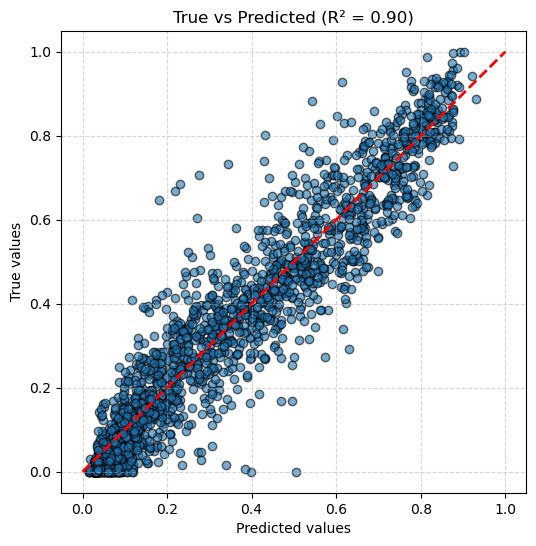

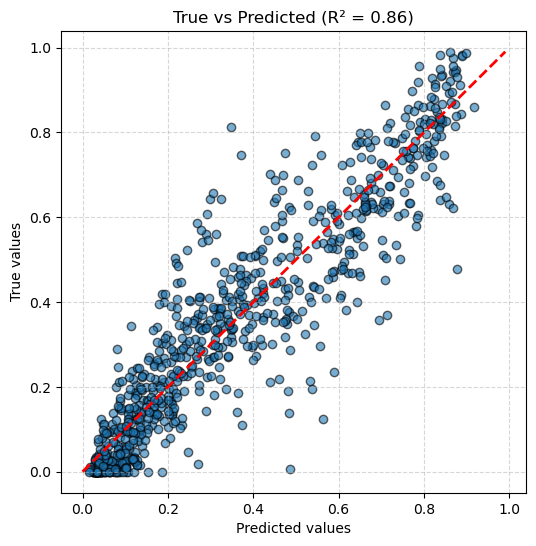

Train R² = 0.90, Val R² = 0.86

Trying lambdas: (1e-05, 0.001, 0.001, 0.003)
 Start iteration: 1;
Updated intercept
Updated beta
Updated gamma
Updated delta
Four ways are 0.
 Start iteration: 2;
Updated intercept
Updated beta
Updated gamma
Updated delta
Four ways are 0.
 Start iteration: 3;
Updated intercept
Updated beta
Updated gamma
Updated delta
Four ways are 0.
The model has converged.


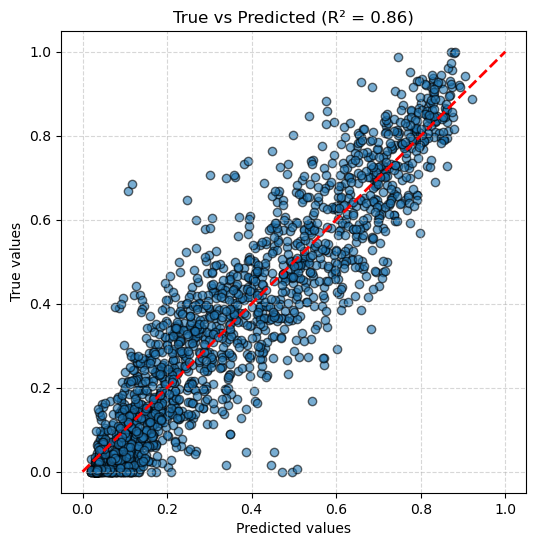

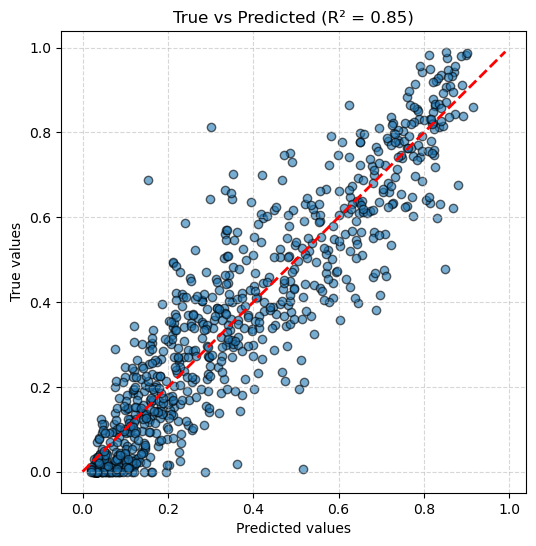

Train R² = 0.86, Val R² = 0.85

Trying lambdas: (0.0001, 0.0001, 0.001, 0.003)
 Start iteration: 1;
Updated intercept
Updated beta
Updated gamma
Updated delta
Four ways are 0.
 Start iteration: 2;
Updated intercept
Updated beta
Updated gamma
Updated delta
Four ways are 0.
 Start iteration: 3;
Updated intercept
Updated beta
Updated gamma
Updated delta
Four ways are 0.
 Start iteration: 4;
Updated intercept
Updated beta
Updated gamma
Updated delta
Four ways are 0.
The model has converged.


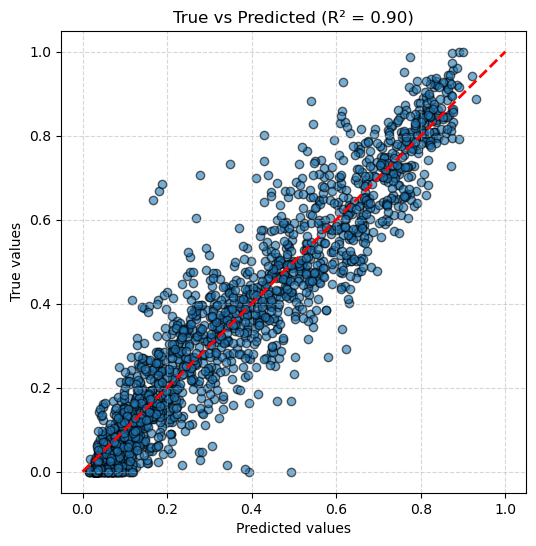

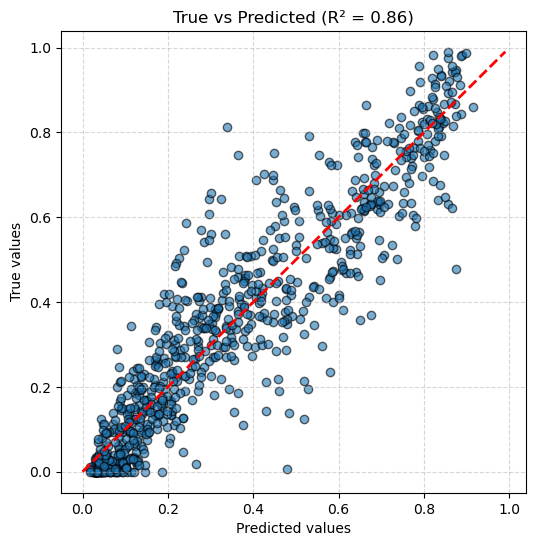

Train R² = 0.90, Val R² = 0.86

Trying lambdas: (0.0001, 0.001, 0.001, 0.003)
 Start iteration: 1;
Updated intercept
Updated beta
Updated gamma
Updated delta
Four ways are 0.
 Start iteration: 2;
Updated intercept
Updated beta
Updated gamma
Updated delta
Four ways are 0.
 Start iteration: 3;
Updated intercept
Updated beta
Updated gamma
Updated delta
Four ways are 0.
The model has converged.


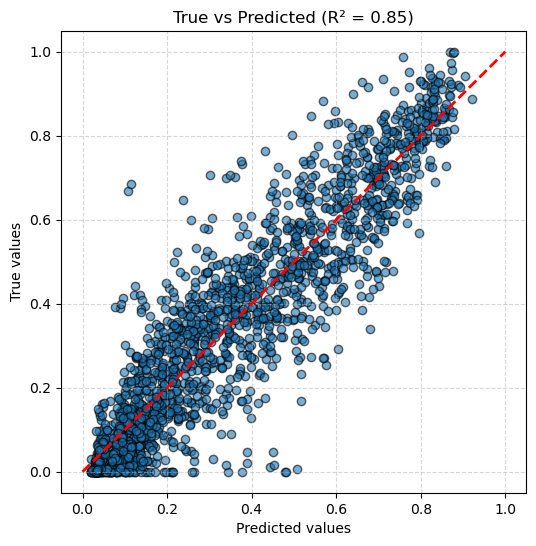

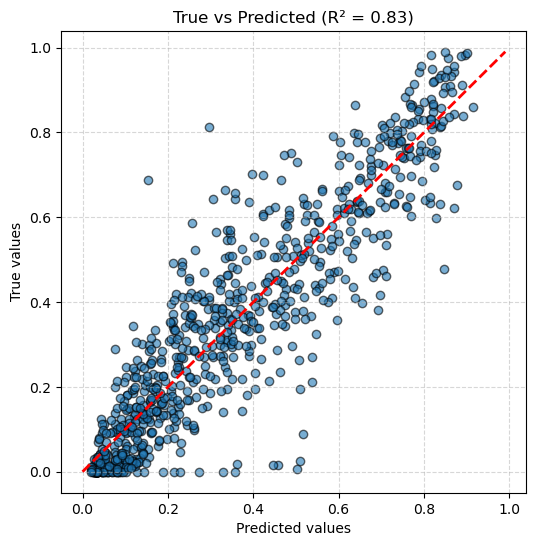

Train R² = 0.85, Val R² = 0.83

Best config on validation: (0.0001, 0.0001, 0.001, 0.003) (Val R² = 0.86)
 Start iteration: 1;
Updated intercept
Updated beta
Updated gamma
Updated delta
Four ways are 0.
 Start iteration: 2;
Updated intercept
Updated beta
Updated gamma
Updated delta
Four ways are 0.
 Start iteration: 3;
Updated intercept
Updated beta
Updated gamma
Updated delta
Four ways are 0.
 Start iteration: 4;
Updated intercept
Updated beta
Updated gamma
Updated delta
Four ways are 0.
The model has converged.
R² score: 0.895021100650498


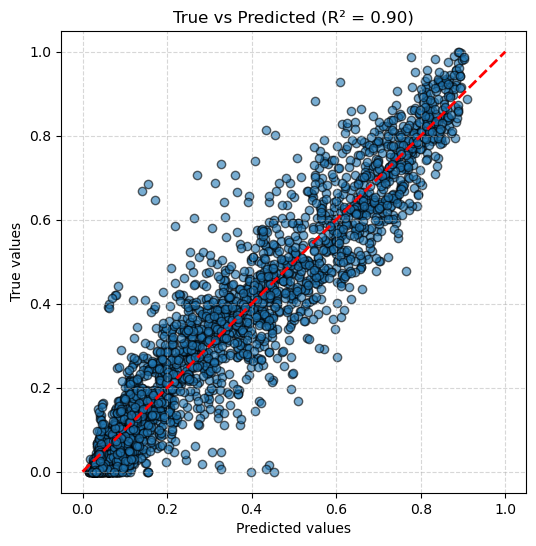


Final Train R² = 0.90
R² score: 0.8479343469113485


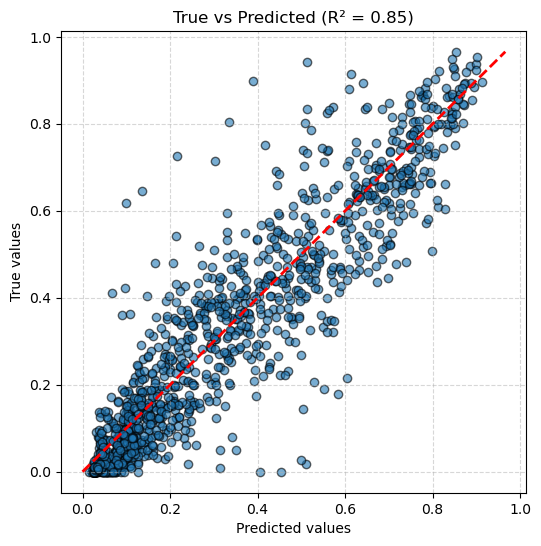


Final Test R² = 0.85
RMSE: 0.10529385265934943

 Final Test RMSE: 0.11


In [2]:

# GRID SEARCH IS USED AS AN EXAMPLE. Model fitting for just 1 set of lambdas takes 30-60 minutes to run depending on the values. Consequently, we let here only 4 combinations as example. Moreover, the prediction is already good.
# One could try even more options for lambdas and maybe get improved prediction. 

rez=grid_search_shim(
    X_train, X_test, y_train, y_test,
    levels_list=levels_list,
    init_list = None,
    lambda_grid=[[1e-5,1e-4],[ 1e-4,1e-3], [ 1e-3], [3e-3]],
    max_iter=10,
    use_init_main = True,
    use_init_main_w = True,
    plot=True, tol=2e-2
)

# How to access the best model from grid_search

In [4]:
best_model=rez[0].model
beta_all=best_model.beta_all
intercept= best_model.intercept

pred_test=best_model.predict(X_test)

print('R2 score on test set: ',np.round( r2_score(y_test,pred_test), 2))


R2 score on test set:  0.85
